### **Customer Churn Intelligence System: Predictive Analytics and Retention Strategy Framework**

In [ ]:
# Import libraries for data analysis and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load customer churn dataset
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
# Display first 5 rows of dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Show dataset information and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Count missing values in each column
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


DATA CLEANING

In [ ]:
# Display unique values and data type
df['TotalCharges'].dtype

dtype('O')

In [ ]:
# Convert TotalCharges into numeric format
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
# Remove rows containing missing values
df.dropna(inplace=True)

In [ ]:
# Drop customer ID because it has no predictive value
df.drop('customerID', axis=1, inplace=True)

### EDA (Exploratory Data Analysis)

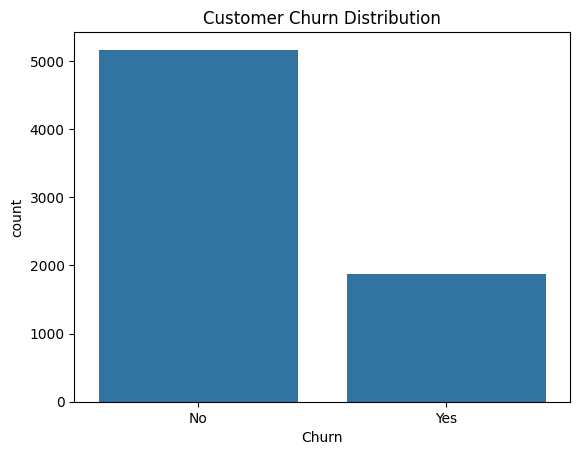

In [ ]:
# Visualize churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

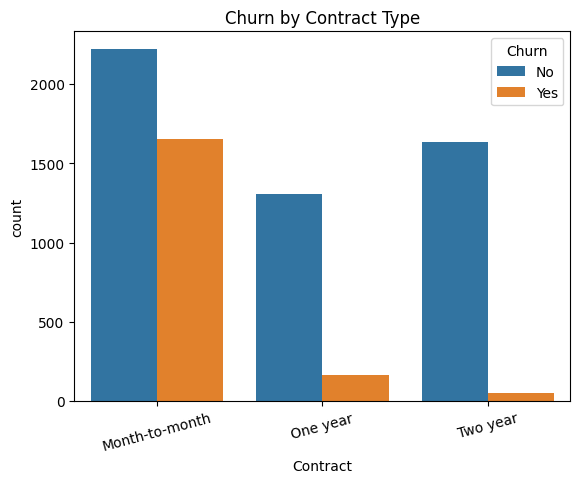

In [ ]:
# Analyze churn by contract type
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

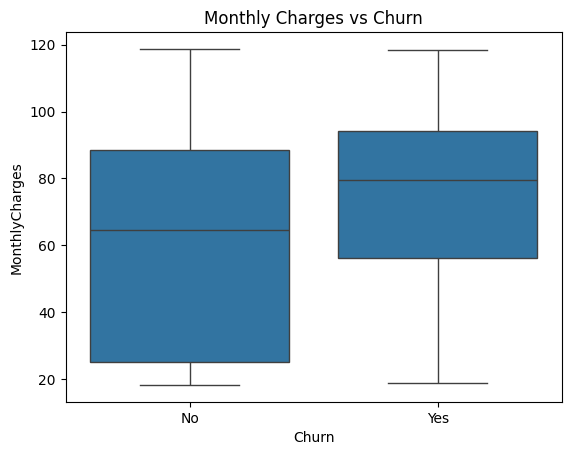

In [ ]:
# Compare monthly charges for churned and retained customers
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

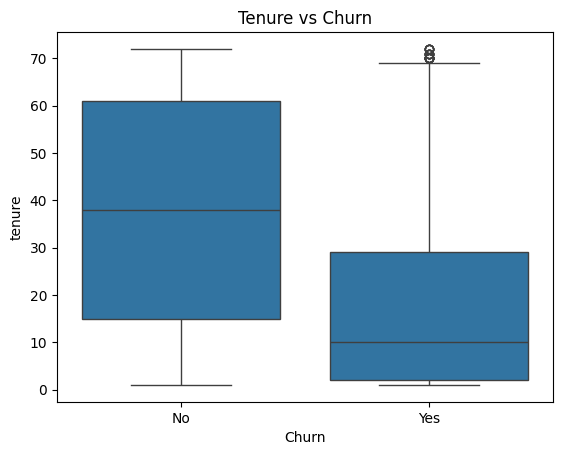

In [ ]:
# Compare tenure with churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

MACHINE LEARNING MODEL


In [ ]:
# Remove extra spaces from Churn values
df['Churn'] = df['Churn'].astype(str).str.strip()

# Convert Churn into numbers
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [ ]:
# Show unique values in Churn column
df['Churn'].unique()

array([0, 1])

In [ ]:
# Check for missing values in target column
df['Churn'].isnull().sum()

np.int64(0)

In [ ]:
# Import Label Encoder
from sklearn.preprocessing import LabelEncoder

# Create encoder object
le = LabelEncoder()

# Convert all text columns into numbers
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
# Select all columns except Churn
X = df.drop('Churn', axis=1)

# Select target column
y = df['Churn']

In [ ]:
# Import train-test split function
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Show unique values in Churn column
print(df['Churn'].unique())

[0 1]


In [ ]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
# Predict churn on test data
lr_predictions = lr_model.predict(X_test)

In [ ]:
# Import accuracy metric
from sklearn.metrics import accuracy_score

# Calculate model accuracy
accuracy = accuracy_score(y_test, lr_predictions)

# Display accuracy
print("Accuracy:", accuracy)

Accuracy: 0.7853589196872779


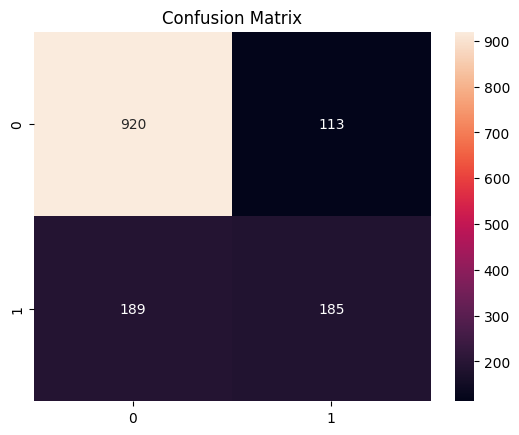

In [ ]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, lr_predictions)

# Display heatmap
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Import classification report
from sklearn.metrics import classification_report

# Display performance report
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [ ]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predict churn
rf_predictions = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Display result
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7924662402274343


In [ ]:
# Display feature importance
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

# Show top 10 important features
importance.sort_values(ascending=False).head(10)

,0
TotalCharges,0.184953
MonthlyCharges,0.178014
tenure,0.154510
Contract,0.080585
PaymentMethod,0.052031
OnlineSecurity,0.048509
TechSupport,0.047581
InternetService,0.026813
gender,0.026715
OnlineBackup,0.025883


In [ ]:
# Display top 10 most important churn factors
importance.sort_values(ascending=False).head(10)

,0
TotalCharges,0.184953
MonthlyCharges,0.178014
tenure,0.154510
Contract,0.080585
PaymentMethod,0.052031
OnlineSecurity,0.048509
TechSupport,0.047581
InternetService,0.026813
gender,0.026715
OnlineBackup,0.025883


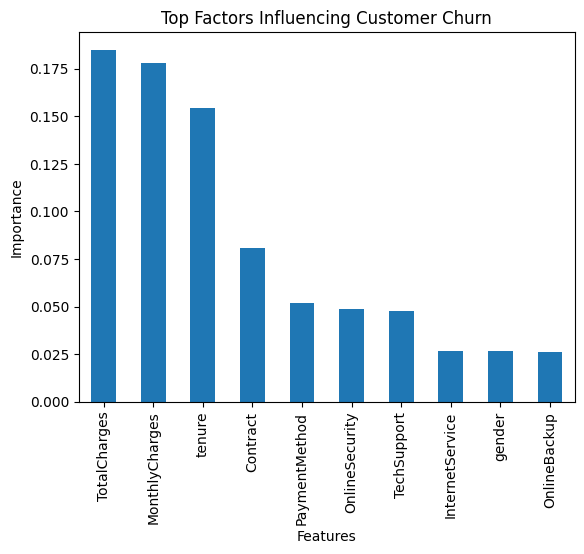

In [ ]:
# Plot top churn factors
importance.sort_values(ascending=False).head(10).plot(kind='bar')

# Add title
plt.title("Top Factors Influencing Customer Churn")

# Add labels
plt.xlabel("Features")
plt.ylabel("Importance")

# Display chart
plt.show()

In [ ]:
# Save machine learning model
import joblib

joblib.dump(rf_model, "churn_model.pkl")

['churn_model.pkl']

In [ ]:
# Save feature names used during training
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [ ]:
# Check generated files
!ls

churn_model.pkl    sample_data
feature_names.pkl  WA_Fn-UseC_-Telco-Customer-Churn.csv
